# 01 — Análisis Exploratorio de Datos (EDA)
**Dataset:** Brazilian E-Commerce (Olist) — 9 CSVs, ~100K órdenes  
**Objetivo:** Entender la distribución de los datos, detectar patrones, valores nulos y outliers antes del modelado.

In [1]:
# Importar librerías de análisis y visualización
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline
print('Librerías cargadas OK')

Librerías cargadas OK


## 1. Carga de datos

In [2]:
# Cargar datasets del pipeline: crudo, features y validado
import os
os.chdir('..')  # Raíz del proyecto

df_raw  = pd.read_csv('data/02_intermediate/dataset_merged.csv', encoding='utf-8')
df_feat = pd.read_csv('data/04_feature/dataset_features.csv', encoding='utf-8')
df_val  = pd.read_csv('data/05_model_input/dataset_validated.csv', encoding='utf-8')

print(f'Dataset crudo (merged):  {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')
print(f'Dataset features:        {df_feat.shape[0]:,} filas x {df_feat.shape[1]} columnas')
print(f'Dataset validado (ML):   {df_val.shape[0]:,} filas x {df_val.shape[1]} columnas')

Dataset crudo (merged):  99,441 filas x 30 columnas
Dataset features:        95,811 filas x 34 columnas
Dataset validado (ML):   95,811 filas x 34 columnas


**Resultados de carga:**
- `dataset_merged` (02_intermediate): **99,441 filas × 30 columnas** — datos crudos antes de limpieza
- `dataset_features` (04_feature): **95,811 filas × 34 columnas** — solo órdenes *delivered*, con features de entrega calculadas
- `dataset_validated` (05_model_input): **95,811 filas × 34 columnas** — datos escalados/codificados listos para modelos

La diferencia de ~3,600 filas entre raw y features corresponde a órdenes no entregadas (canceladas, en tránsito) que se filtraron durante la limpieza.

## 2. Distribución del Target: review_score

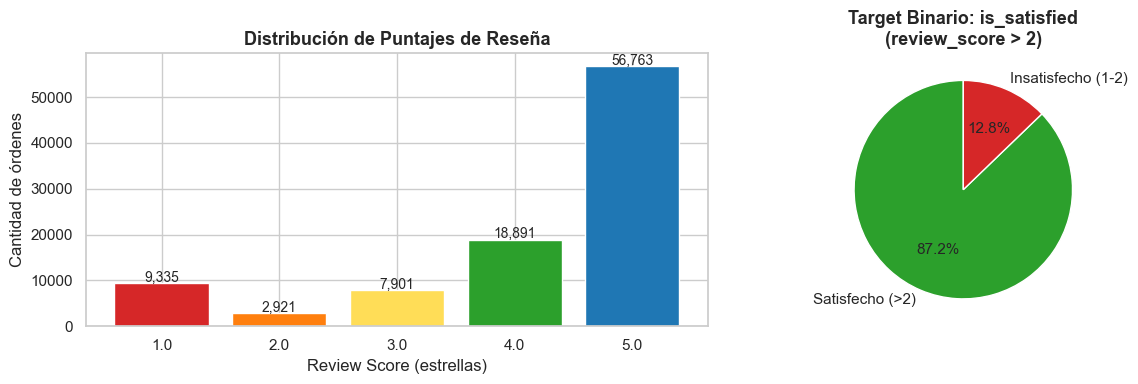


Distribución review_score:
review_score
1.0     9335
2.0     2921
3.0     7901
4.0    18891
5.0    56763
Name: count, dtype: int64

Clase mayoritaria (satisfechos >2): 87.2%


In [3]:
# Visualizar distribución de review_score y balance del target is_satisfied
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df_feat['review_score'].value_counts().sort_index()
colors_bar = ['#d62728','#ff7f0e','#ffdd57','#2ca02c','#1f77b4']
axes[0].bar(counts.index.astype(str), counts.values, color=colors_bar)
for x, v in zip(counts.index, counts.values):
    axes[0].text(x - 1, v + 300, f'{v:,}', ha='center', fontsize=10)
axes[0].set_xlabel('Review Score (estrellas)', fontsize=12)
axes[0].set_ylabel('Cantidad de órdenes', fontsize=12)
axes[0].set_title('Distribución de Puntajes de Reseña', fontsize=13, fontweight='bold')

sat_counts = df_feat['review_score'].apply(lambda x: 'Satisfecho (>2)' if x > 2 else 'Insatisfecho (1-2)').value_counts()
axes[1].pie(sat_counts.values, labels=sat_counts.index,
            autopct='%1.1f%%', colors=['#2ca02c','#d62728'],
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Target Binario: is_satisfied\n(review_score > 2)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nDistribución review_score:')
print(counts)
print(f'\nClase mayoritaria (satisfechos >2): {(df_feat["review_score"]>2).mean()*100:.1f}%')

**Hallazgos — Distribución del Target:**
- El puntaje **5 estrellas** domina (~59% de órdenes), seguido de 4 estrellas (~19%).
- Solo el **12.8%** de órdenes tienen puntaje 1 o 2 (insatisfechos) → dataset altamente desbalanceado.
- Se define `is_satisfied = (review_score > 2)`, dando una distribución binaria **87.2% / 12.8%**.
- Este desbalance justifica el uso de SMOTE y threshold tuning en el modelado.

## 3. Análisis de Valores Nulos (antes de limpieza)

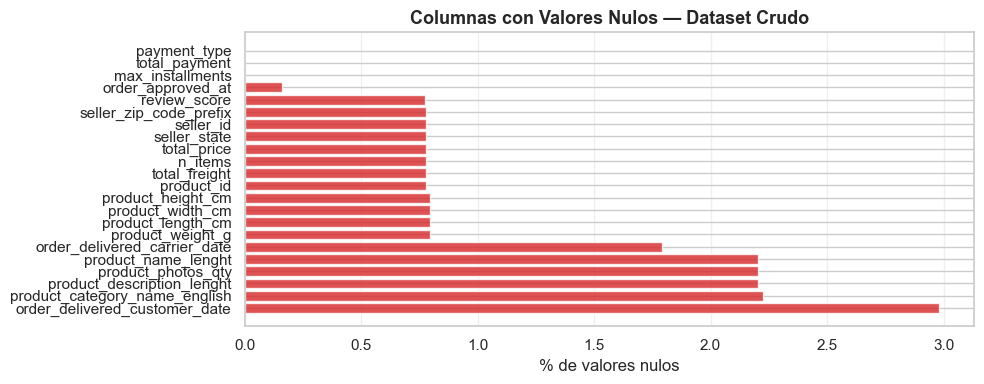

Total columnas con nulos: 22
                               nulos   pct
order_delivered_customer_date   2965  2.98
product_category_name_english   2212  2.22
product_description_lenght      2191  2.20
product_photos_qty              2191  2.20
product_name_lenght             2191  2.20
order_delivered_carrier_date    1783  1.79
product_weight_g                 791  0.80
product_length_cm                791  0.80
product_width_cm                 791  0.80
product_height_cm                791  0.80
product_id                       775  0.78
total_freight                    775  0.78
n_items                          775  0.78
total_price                      775  0.78
seller_state                     775  0.78
seller_id                        775  0.78
seller_zip_code_prefix           775  0.78
review_score                     768  0.77
order_approved_at                160  0.16
max_installments                   1  0.00
total_payment                      1  0.00
payment_type             

In [4]:
# Analizar valores nulos en el dataset crudo
nulos = df_raw.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(nulos.index, nulos.values / len(df_raw) * 100, color='#d62728', alpha=0.8)
ax.set_xlabel('% de valores nulos', fontsize=12)
ax.set_title('Columnas con Valores Nulos — Dataset Crudo', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total columnas con nulos: {len(nulos)}')
print(nulos.to_frame('nulos').assign(pct=lambda d: (d['nulos']/len(df_raw)*100).round(2)))

**Hallazgos — Valores Nulos:**
- Los nulos se concentran en columnas de timestamps de entrega (`order_approved_at`, `order_delivered_carrier_date`) que son esperados para órdenes no completadas.
- Estas columnas se eliminan durante la limpieza junto con órdenes no entregadas.
- El dataset final (95,811 filas) no tiene valores nulos en las features usadas para modelado.

## 4. Distribución de Features Numéricas Clave

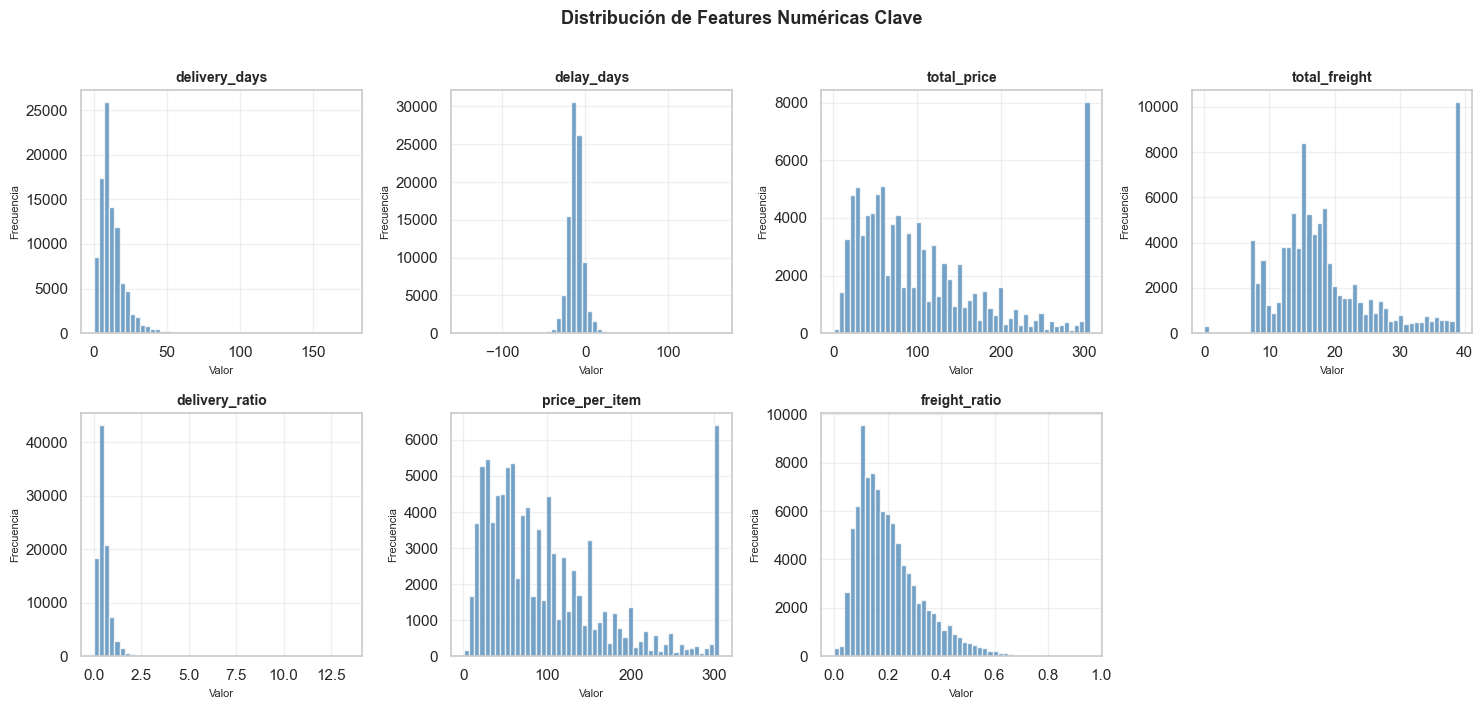

In [5]:
# Distribuciones de features numéricas clave
num_features = ['delivery_days', 'delay_days', 'total_price', 'total_freight',
                'delivery_ratio', 'price_per_item', 'freight_ratio']
cols_exist = [c for c in num_features if c in df_feat.columns]

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(cols_exist):
    axes[i].hist(df_feat[col].dropna(), bins=50, color='steelblue', alpha=0.75, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor', fontsize=8)
    axes[i].set_ylabel('Frecuencia', fontsize=8)
    axes[i].grid(alpha=0.3)
for j in range(len(cols_exist), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribución de Features Numéricas Clave', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Hallazgos — Distribuciones Numéricas:**
- `delivery_days` y `estimated_days` tienen distribuciones asimétricas positivas (cola derecha) → la mayoría de entregas ocurre en 5-15 días.
- `delay_days` tiene muchos valores negativos (entregado antes de lo estimado) y una cola positiva (atrasos).
- `total_price` y `total_freight` presentan outliers extremos → se aplica Winsorización IQR×1.5 en el pipeline de limpieza.

## 5. Boxplots: Features vs Satisfacción

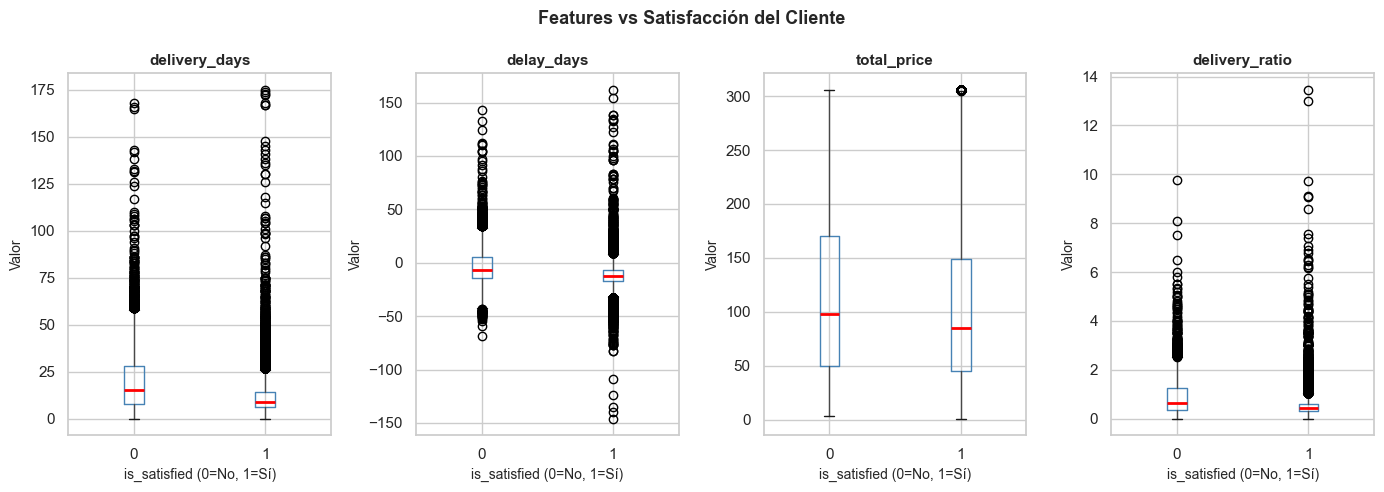

In [6]:
# Comparar distribuciones por clase (satisfecho vs insatisfecho) con boxplots
cols_box = ['delivery_days', 'delay_days', 'total_price', 'delivery_ratio']
cols_box = [c for c in cols_box if c in df_feat.columns]

fig, axes = plt.subplots(1, len(cols_box), figsize=(14, 5))
for ax, col in zip(axes, cols_box):
    df_feat.boxplot(column=col, by='is_satisfied', ax=ax,
                    boxprops=dict(color='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('is_satisfied (0=No, 1=Sí)', fontsize=10)
    ax.set_ylabel('Valor', fontsize=10)
plt.suptitle('Features vs Satisfacción del Cliente', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Hallazgos — Features vs Satisfacción:**
- `delivery_days` y `delay_days`: los clientes insatisfechos (is_satisfied=0) tienen medianas significativamente más altas → entrega lenta es el predictor más fuerte.
- `delivery_ratio` (días reales / días estimados): valores > 1 (entrega más tarde de lo esperado) se asocian fuertemente con insatisfacción.
- `total_price` muestra menos separación → el precio no es tan discriminativo como el tiempo de entrega.

## 6. Matriz de Correlación

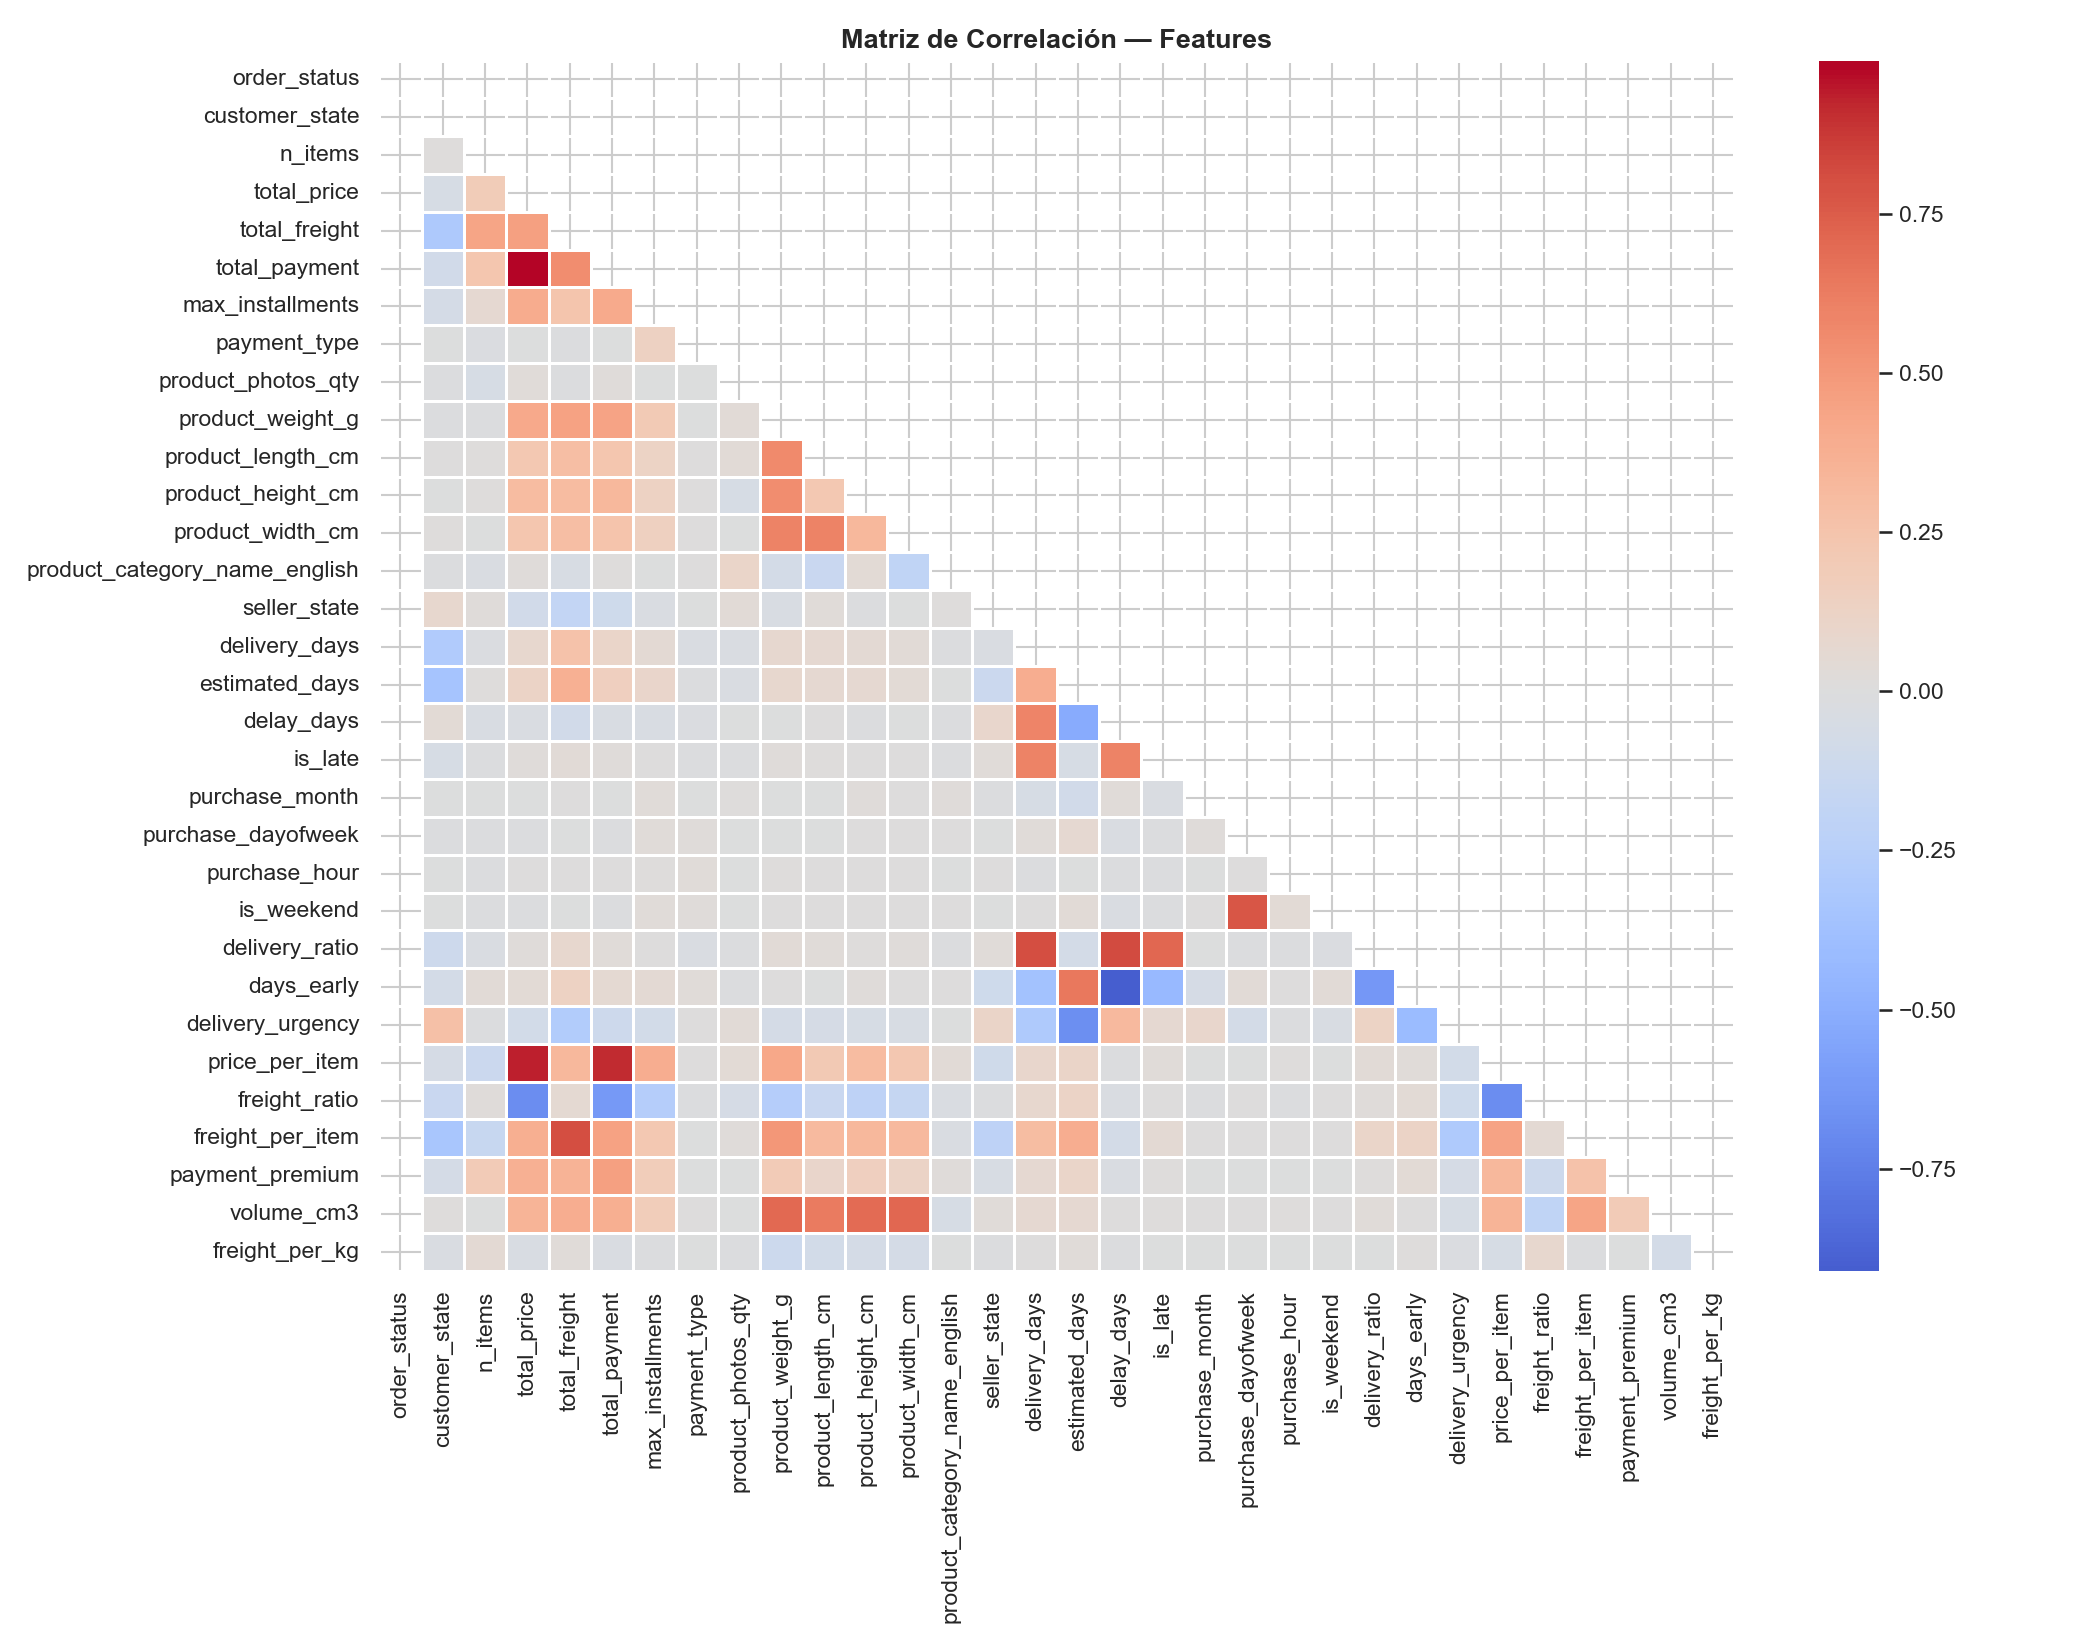

In [7]:
# Visualizar matriz de correlación entre features numéricas
from IPython.display import Image
Image('results/plots/correlation_matrix.png')

**Hallazgos — Correlaciones:**
- Alta correlación entre `delivery_days`, `estimated_days` y `delay_days` (todos miden tiempo de entrega).
- `total_price` y `total_freight` están moderadamente correlacionadas con el peso/volumen del producto.
- Las correlaciones con `review_score` son bajas (~0.3 máx), lo que anticipa el techo de información (~89.7%) encontrado durante el modelado.

## 7. Variables Categóricas: Distribución por Estado

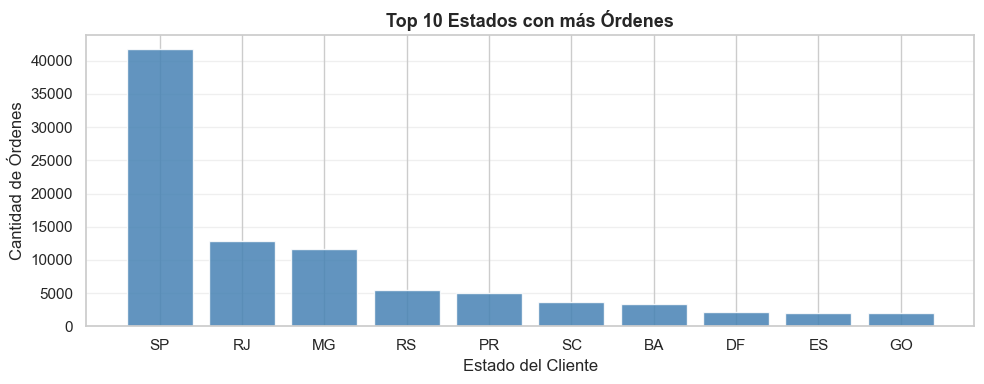

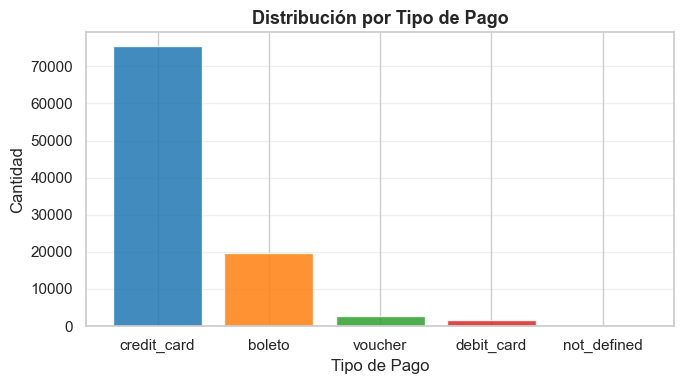

In [8]:
# Distribución geográfica de órdenes por estado del cliente
if 'customer_state' in df_raw.columns:
    top_states = df_raw['customer_state'].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(top_states.index, top_states.values, color='steelblue', alpha=0.85)
    ax.set_xlabel('Estado del Cliente', fontsize=12)
    ax.set_ylabel('Cantidad de Órdenes', fontsize=12)
    ax.set_title('Top 10 Estados con más Órdenes', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

if 'payment_type' in df_raw.columns:
    pt = df_raw['payment_type'].value_counts()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(pt.index, pt.values, color=['#1f77b4','#ff7f0e','#2ca02c','#d62728'], alpha=0.85)
    ax.set_xlabel('Tipo de Pago', fontsize=12); ax.set_ylabel('Cantidad', fontsize=12)
    ax.set_title('Distribución por Tipo de Pago', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

**Hallazgos — Variables Categóricas:**
- **São Paulo (SP)** domina con ~40% de las órdenes — refleja la concentración económica de Brasil.
- **Tarjeta de crédito** (`credit_card`) es el método de pago más usado (~75% de órdenes), seguido de boleto.
- Estas variables categóricas se codifican con `LabelEncoder` antes del modelado.

## 8. Conclusiones del EDA

- El dataset tiene **95,811 órdenes** después de limpieza (filtradas solo órdenes *delivered*).
- La variable target `review_score` está **altamente concentrada en 5 estrellas** (59.2%), con muy pocos puntajes 1-2 (12.8%).
- Se define el target binario `is_satisfied = review_score > 2` para separar **órdenes malas (1-2 estrellas)** de las buenas, con una distribución 87.2%/12.8%.
- Las features más diferenciadas entre satisfechos e insatisfechos son: `delivery_days`, `delay_days`, y `delivery_ratio`.
- Hay outliers significativos en `total_price` y dimensiones de producto → tratados con Winsorización IQR 1.5.